2.1 理论计算题

向量 a = [2, -1, 3]^T, b = [1, 4, -2]^T
矩阵 A = [ [1,0], [3,2] ], B = [ [2,0], [3,1] ]

1. 点积 a·b = 2*1 + (-1)*4 + 3*(-2) = -8

2. 矩阵乘法 A×B = [ [1*2+0*3, 1*0+0*1], [3*2+2*3, 3*0+2*1] ] = [ [2, 0], [12, 2] ]，形状 2×2

3. Frobenius范数 ||a||_F = sqrt(2^2 + (-1)^2 + 3^2) = sqrt(14)

In [ ]:
# 2.2 编程题（NumPy实现）
import numpy as np

# 1. 创建形状为3×4的随机矩阵X，元素服从标准正态分布
np.random.seed(42)  # 固定随机种子便于复现
X = np.random.randn(3, 4)

# 2. 创建形状为4×2的全1矩阵Y
Y = np.ones((4, 2))

# 3. 计算矩阵乘法 Z = X × Y
Z = X @ Y  # 或 np.dot(X, Y)

# 4. 输出Z的第一行和第二列交叉处的元素，以及Z的第2行所有元素
elem = Z[0, 1]        # 第一行（索引0），第二列（索引1）
row2 = Z[1, :]        # 第二行（索引1）所有列

print("Z =", Z)
print("第一行第二列元素:", elem)
print("第二行所有元素:", row2)

# 5. 计算Z的Frobenius范数
frob_norm = np.linalg.norm(Z, 'fro')
print("Z的Frobenius范数:", frob_norm)

Z = [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]
第一行第二列元素: 2.5291682463487657
第二行所有元素: [1.87835721 1.87835721]
Z的Frobenius范数: 4.616873319476864


3.1 贝叶斯公式
患病率 P(D)=0.001，灵敏度 P(+|D)=0.99，假阳性率 P(+|非D)=0.02
P(+) = 0.001*0.99 + 0.999*0.02 = 0.02097
P(D|+) = 0.00099 / 0.02097 ≈ 0.04721 = 4.72%


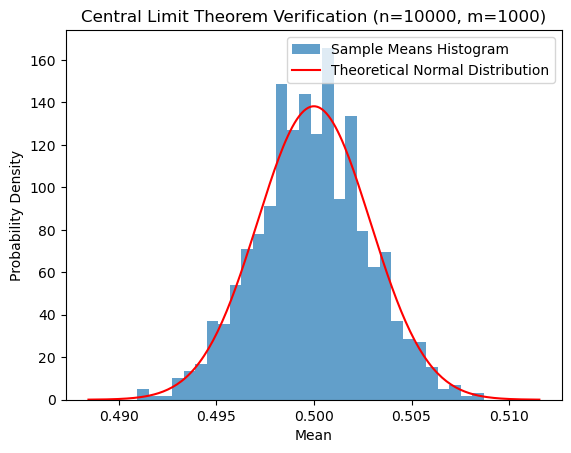

Actual variance: 0.00000804
Theoretical variance: 0.00000833


In [ ]:
# 3.2 编程题（中心极限定理模拟）
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
n = 10000      # sample size per estimate
m = 1000       # number of repetitions

# Simulation: generate m sample means
means = []
for _ in range(m):
    sample = np.random.uniform(0, 1, n)
    means.append(np.mean(sample))
means = np.array(means)

# Theoretical distribution: Uniform(0,1) mean = 0.5, variance = 1/(12n)
mu_theory = 0.5
var_theory = 1 / (12 * n)
std_theory = np.sqrt(var_theory)

# Plot histogram
plt.hist(means, bins=30, density=True, alpha=0.7, label='Sample Means Histogram')

# Overlay theoretical normal distribution curve
x = np.linspace(mu_theory - 4*std_theory, mu_theory + 4*std_theory, 200)
plt.plot(x, norm.pdf(x, mu_theory, std_theory), 'r-', label='Theoretical Normal Distribution')

plt.xlabel('Mean')
plt.ylabel('Probability Density')
plt.title('Central Limit Theorem Verification (n=10000, m=1000)')
plt.legend()
plt.show()

# Compute actual variance
actual_var = np.var(means)
print(f"Actual variance: {actual_var:.8f}")
print(f"Theoretical variance: {var_theory:.8f}")


4.1 偏导数

z = (2w1 + w2 - 3)^2
∂z/∂w1 = 4(2w1 + w2 - 3)
∂z/∂w2 = 2(2w1 + w2 - 3)
当 w1=0.5, w2=1 时，2w1+w2-3 = -1，所以 ∂z/∂w1 = -4，∂z/∂w2 = -2

In [ ]:
# 4.2 编程题（手动反向传播与自动微分对比）
import torch

# 手动前向与反向
x = 2.0
w1 = 1.5
w2 = 0.5

# 前向
a = x * w1
b = a + w2
L = b ** 2
print(f"前向结果 L = {L}")

# 手动链式法则
dL_db = 2 * b          # L = b^2
db_da = 1.0
da_dw1 = x
db_dw2 = 1.0

dL_dw1 = dL_db * db_da * da_dw1   # = 2b * 1 * x
dL_dw2 = dL_db * db_dw2           # = 2b * 1

print(f"手动梯度: dL/dw1 = {dL_dw1}, dL/dw2 = {dL_dw2}")

# 使用PyTorch自动微分验证
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print(f"自动微分梯度: dL/dw1 = {w1_t.grad.item()}, dL/dw2 = {w2_t.grad.item()}")

前向结果 L = 12.25
手动梯度: dL/dw1 = 14.0, dL/dw2 = 7.0
自动微分梯度: dL/dw1 = 14.0, dL/dw2 = 7.0


5.1 线性回归梯度

L = (1/n) * Σ (yi - w*xi - b)^2
∂L/∂w = -(2/n) * Σ (yi - w*xi - b) * xi
∂L/∂b = -(2/n) * Σ (yi - w*xi - b)

In [ ]:
#5.2 从零实现Softmax回归对MNIST分类
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 加载数据（digits数据集，8x8图像，共10类）
digits = load_digits()
X = digits.data          # (1797, 64)
y = digits.target.reshape(-1, 1)   # (1797, 1)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot编码标签
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)  # (n_train, 10)
y_test_onehot = encoder.transform(y_test)

# 参数初始化
input_dim = X_train.shape[1]   # 64
num_classes = 10
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros((1, num_classes))

# Softmax函数
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 交叉熵损失（带梯度）
def cross_entropy_loss(X, y, W, b):
    n = X.shape[0]
    logits = X @ W + b
    probs = softmax(logits)
    loss = -np.mean(np.sum(y * np.log(probs + 1e-8), axis=1))
    return loss

def compute_gradients(X, y, W, b):
    n = X.shape[0]
    logits = X @ W + b
    probs = softmax(logits)
    grad_logits = probs - y          # (n, num_classes)
    grad_W = (X.T @ grad_logits) / n
    grad_b = np.mean(grad_logits, axis=0, keepdims=True)
    return grad_W, grad_b

# 小批量SGD训练
epochs = 50
batch_size = 32
learning_rate = 0.1

for epoch in range(epochs):
    # 随机打乱数据
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        grad_W, grad_b = compute_gradients(X_batch, y_batch, W, b)
        W -= learning_rate * grad_W
        b -= learning_rate * grad_b
    
    # 每10个epoch输出一次损失
    if (epoch+1) % 10 == 0:
        loss = cross_entropy_loss(X_train, y_train_onehot, W, b)
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

# 测试准确率
def predict(X, W, b):
    logits = X @ W + b
    return np.argmax(logits, axis=1)

y_pred = predict(X_test, W, b)
y_true = y_test.flatten()
accuracy = np.mean(y_pred == y_true)
print(f"测试集准确率: {accuracy:.4f}")

Epoch 10, Loss: 0.3794
Epoch 20, Loss: 0.6029
Epoch 30, Loss: 0.0042
Epoch 40, Loss: 0.0002
Epoch 50, Loss: 0.0002
测试集准确率: 0.9667


6.1 正态分布 MLE

样本 x1..xn ~ N(μ, σ^2)
μ的MLE = (1/n) Σ xi
σ^2的MLE = (1/n) Σ (xi - μ的MLE)^2